# SFUMATO — Full pipeline example

This notebook walks through the complete SFUMATO pipeline:

1. Usage on public toy dataset (https://tissuumaps-demo.serve.scilifelab.se/p2r_mousebrain.tmap)
2. Preprocess: spatial binning + sparse SVD
3. BGM clustering at multiple resolutions (K = 10, 15, 20)
4. Visualise: multiresolution dendrogram, spatial maps, uncertainty, cluster posteriors

> **Requirements:** a CUDA GPU is needed for the BGM step.  
> The preprocessing step runs on CPU.


---
## 0. Imports & SFUMATO path

In [1]:
import sys
from pathlib import Path

import numpy as np
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── SFUMATO root ──────────────────────────────────────────────────────────────
# If this notebook is in notebooks/examples/, the SFUMATO root is two levels up.
# Adjust if you placed the notebook elsewhere.
SFUMATO_ROOT = Path("../..").resolve()
if str(SFUMATO_ROOT) not in sys.path:
    sys.path.insert(0, str(SFUMATO_ROOT))

from preprocess import run_preprocess
from run_bgm_gpu import run_bgm
from utils_bgm import (
    BGMConfig,
    bgm_stem_for,
    result_dir_for,
    shared_result_dir_for,
    shared_bgm_stem_for,
    shared_image_dir_for,
)

print(f"SFUMATO root: {SFUMATO_ROOT}")

c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\spatialdata\_core\query\relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in futur

SFUMATO root: C:\Users\alegi784\Desktop\sfumato_example


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\site-packages\anndata\__init__.py:70: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)


---
## 1. GPU check

The BGM step requires a CUDA GPU. The cell below will raise an error if none is found.

In [2]:
import torch

if not torch.cuda.is_available():
    raise EnvironmentError(
        "No CUDA GPU detected. SFUMATO BGM requires a GPU.\n"
        "Make sure you are on a machine with a CUDA-capable GPU and that "
        "the correct version of PyTorch (with CUDA) is installed."
    )

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


---
## 2. Download toy data

Mouse cortex MERFISH data (~500k transcripts). Same dataset used by the Points2Regions demo.  
Columns: `X`, `Y`, `Genes`.

In [3]:
DATA_PATH = r"C:\Users\alegi784\Desktop\sfumato_example\SFUMATO-main\SFUMATO-main\data\toy_data.csv"

df_raw = pd.read_csv(DATA_PATH)

print(f"{len(df_raw):,} transcripts, {df_raw['Gene'].nunique()} genes")
df_raw.head()

1,955,408 transcripts, 97 genes


,X,Y,letters,Gene
0,4597,17828,ATCCC,Pcp4
1,12461,2784,TTGCC,Neurod6
2,24301,16945,GACTG,Pvalb
3,5177,16963,CAATG,Enc1
4,28201,13956,CACCC,Calm2


In [4]:
print(df_raw.shape)
print(df_raw["X"].min(), df_raw["X"].max())
print(df_raw["Y"].min(), df_raw["Y"].max())
print(df_raw["Gene"].nunique())

(1955408, 4)
386 33311
4 22490
97


---
## 3. Configuration

All SFUMATO parameters live in one dictionary — the same structure as a JSON config file.  
Edit this cell to match your data.

In [13]:
config = {
    "run_name":  "toy_cortex",
    "input_csv": str(DATA_PATH),

    # Column names in the input CSV
    "columns": {
        "x":      "X",
        "y":      "Y",
        "gene":   "Gene",
        "num_id": None,        # set to None if your data has no numeric transcript ID
    },

    "preprocess": {
        "k_list":             [10, 15, 20],   # resolutions to produce
        "bgm_oversample":     1.5,            # K_bgm = ceil(oversample * max(k_list))
        "min_genes_per_bin":  10,             # bins with fewer transcripts are dropped
        "bin_width":          50,            # spatial bin size in the same units as X/Y
        "factor":             4,              # smoothing factor for Points2Regions
        "seed":               8,
        "comp":               10,             # number of SVD components
        "save_p2r":           False,          # skip P2R reference clustering
        "alpha":              1.0,
        "cache_dir":          "preprocess_cache_toy_cortex",
    },

    "bgm": {
        "outroot":              "results_toy_cortex",
        "save_transcript_proba": False,
        "merge_method":          "complete",
        "merge_metric":          "cosine",
        "bgm_weight_prior":      1,
    },

    "color": {
        "colormap":               "gist_ncar",
        "colormap_start":          0.08,
        "colormap_end":            0.92,
        "dendrogram_branch_linewidth": 3.0,
    },
}

print("Config ready.")
print(f"  K_list:    {config['preprocess']['k_list']}")
print(f"  K_bgm:     {int(__import__('math').ceil(config['preprocess']['bgm_oversample'] * max(config['preprocess']['k_list'])))}")
print(f"  bin_width: {config['preprocess']['bin_width']}")
print(f"  SVD comp:  {config['preprocess']['comp']}")

Config ready.
  K_list:    [10, 15, 20]
  K_bgm:     30
  bin_width: 50
  SVD comp:  10


---
## 4. Preprocessing

Runs Points2Regions feature extraction followed by sparse TruncatedSVD.  
Output is saved to `preprocess_cache_toy_cortex/` and reused on subsequent runs.

> **Command-line equivalent:**
> ```bash
> python preprocess.py --config configs/your_config.json
> # add --force to overwrite an existing cache
> ```

In [14]:
run_preprocess(config, force=True)
print("Preprocessing done.")

Reading input CSV: C:\Users\alegi784\Desktop\sfumato_example\SFUMATO-main\SFUMATO-main\data\toy_data.csv
There are 97 gene types
Running points2regions once for this run...
  Good bins: 187,013 / 195,154
  X_all sparse: (187013, 97), nnz=10,373,017
TruncatedSVD (10 components)...
  Explained variance: [0.028 0.207 0.083 0.072 0.051 0.037 0.028 0.025 0.021 0.017]
  Cumulative: 0.569
Saving cache to preprocess_cache_toy_cortex\toy_cortex_BIN50_F4_SVD10.npz...
  Saved preprocess_cache_toy_cortex\toy_cortex_BIN50_F4_SVD10.npz
  X_norm: (187013, 10), 7.5 MB
Preprocessing done.


---
## 5. BGM clustering

Fits one oversampled Bayesian Gaussian Mixture with `K_bgm = ceil(1.5 × 20) = 30` components,  
builds a shared dendrogram, and cuts it at K = 10, 15, 20.

> **Command-line equivalent:**
> ```bash
> python run_bgm_gpu.py --config configs/your_config.json
> # or run both steps at once:
> python run_sfumato.py --config configs/your_config.json
> ```

In [15]:
run_bgm(config)
print("BGM done.")

CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Loading cache from preprocess_cache_toy_cortex\toy_cortex_BIN50_F4_SVD10.npz...
  X_norm: (187013, 10)

Shared BGM run
K_LIST=[10, 15, 20]
K_max=20
bgm_oversample=1.5
K_bgm=30
oversample=True
Output directory: results_toy_cortex\shared_BGM\SVD10
BGM (30 components, 10 dims)...
Initialization 1/1
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
  Iteration 120
  Iteration 130
  Iteration 140
  Iteration 150
  Iteration 160
  Iteration 170
  Iteration 180
  Iteration 190
  Iteration 200
  Iteration 210
  Iteration 220
  Iteration 230
  Iteration 240
  Iteration 250
  Iteration 260
  Iteration 270
  Iteration 280
  Using soft centroids for shared dendrogram
  Saved results_toy_cortex\shared_BGM\SVD10\toy_cortex_BGM30toMAX20_BIN50_F4_SVD10_oversampled_merge_distances.csv
  Saved results_toy_cortex\shared_BGM\SVD10

c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  Saved results_toy_cortex\K10\SVD10\toy_cortex_BGM30to10_BIN50_F4_SVD10_FULL.h5ad
  Saved results_toy_cortex\K10\SVD10\toy_cortex_BGM30to10_BIN50_F4_SVD10_binlevel_FULL.csv
  Saved results_toy_cortex\K10\SVD10\weights_toy_cortex_BGM30to10_BIN50_F4_SVD10.txt
  Skipped transcript-level probability CSV.
  Done K=10

Cutting shared dendrogram to K=15
Output directory: results_toy_cortex\K15\SVD10
  Final clusters: 15
  Saved cut dendrogram for K=15
  Saved results_toy_cortex\K15\SVD10\colors_toy_cortex_BGM30to15_BIN50_F4_SVD10.csv


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  Saved results_toy_cortex\K15\SVD10\toy_cortex_BGM30to15_BIN50_F4_SVD10_FULL.h5ad
  Saved results_toy_cortex\K15\SVD10\toy_cortex_BGM30to15_BIN50_F4_SVD10_binlevel_FULL.csv
  Saved results_toy_cortex\K15\SVD10\weights_toy_cortex_BGM30to15_BIN50_F4_SVD10.txt
  Skipped transcript-level probability CSV.
  Done K=15

Cutting shared dendrogram to K=20
Output directory: results_toy_cortex\K20\SVD10
  Final clusters: 20
  Saved cut dendrogram for K=20
  Saved results_toy_cortex\K20\SVD10\colors_toy_cortex_BGM30to20_BIN50_F4_SVD10.csv


c:\Users\alegi784\AppData\Local\anaconda3\envs\gene_analysis\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  Saved results_toy_cortex\K20\SVD10\toy_cortex_BGM30to20_BIN50_F4_SVD10_FULL.h5ad
  Saved results_toy_cortex\K20\SVD10\toy_cortex_BGM30to20_BIN50_F4_SVD10_binlevel_FULL.csv
  Saved results_toy_cortex\K20\SVD10\weights_toy_cortex_BGM30to20_BIN50_F4_SVD10.txt
  Skipped transcript-level probability CSV.
  Done K=20
BGM done.


---
## 6. Results

### 6.1 Multiresolution dendrogram

The shared dendrogram shows all three K cuts on the same oversampled component tree.  
Branches are coloured consistently across resolutions.

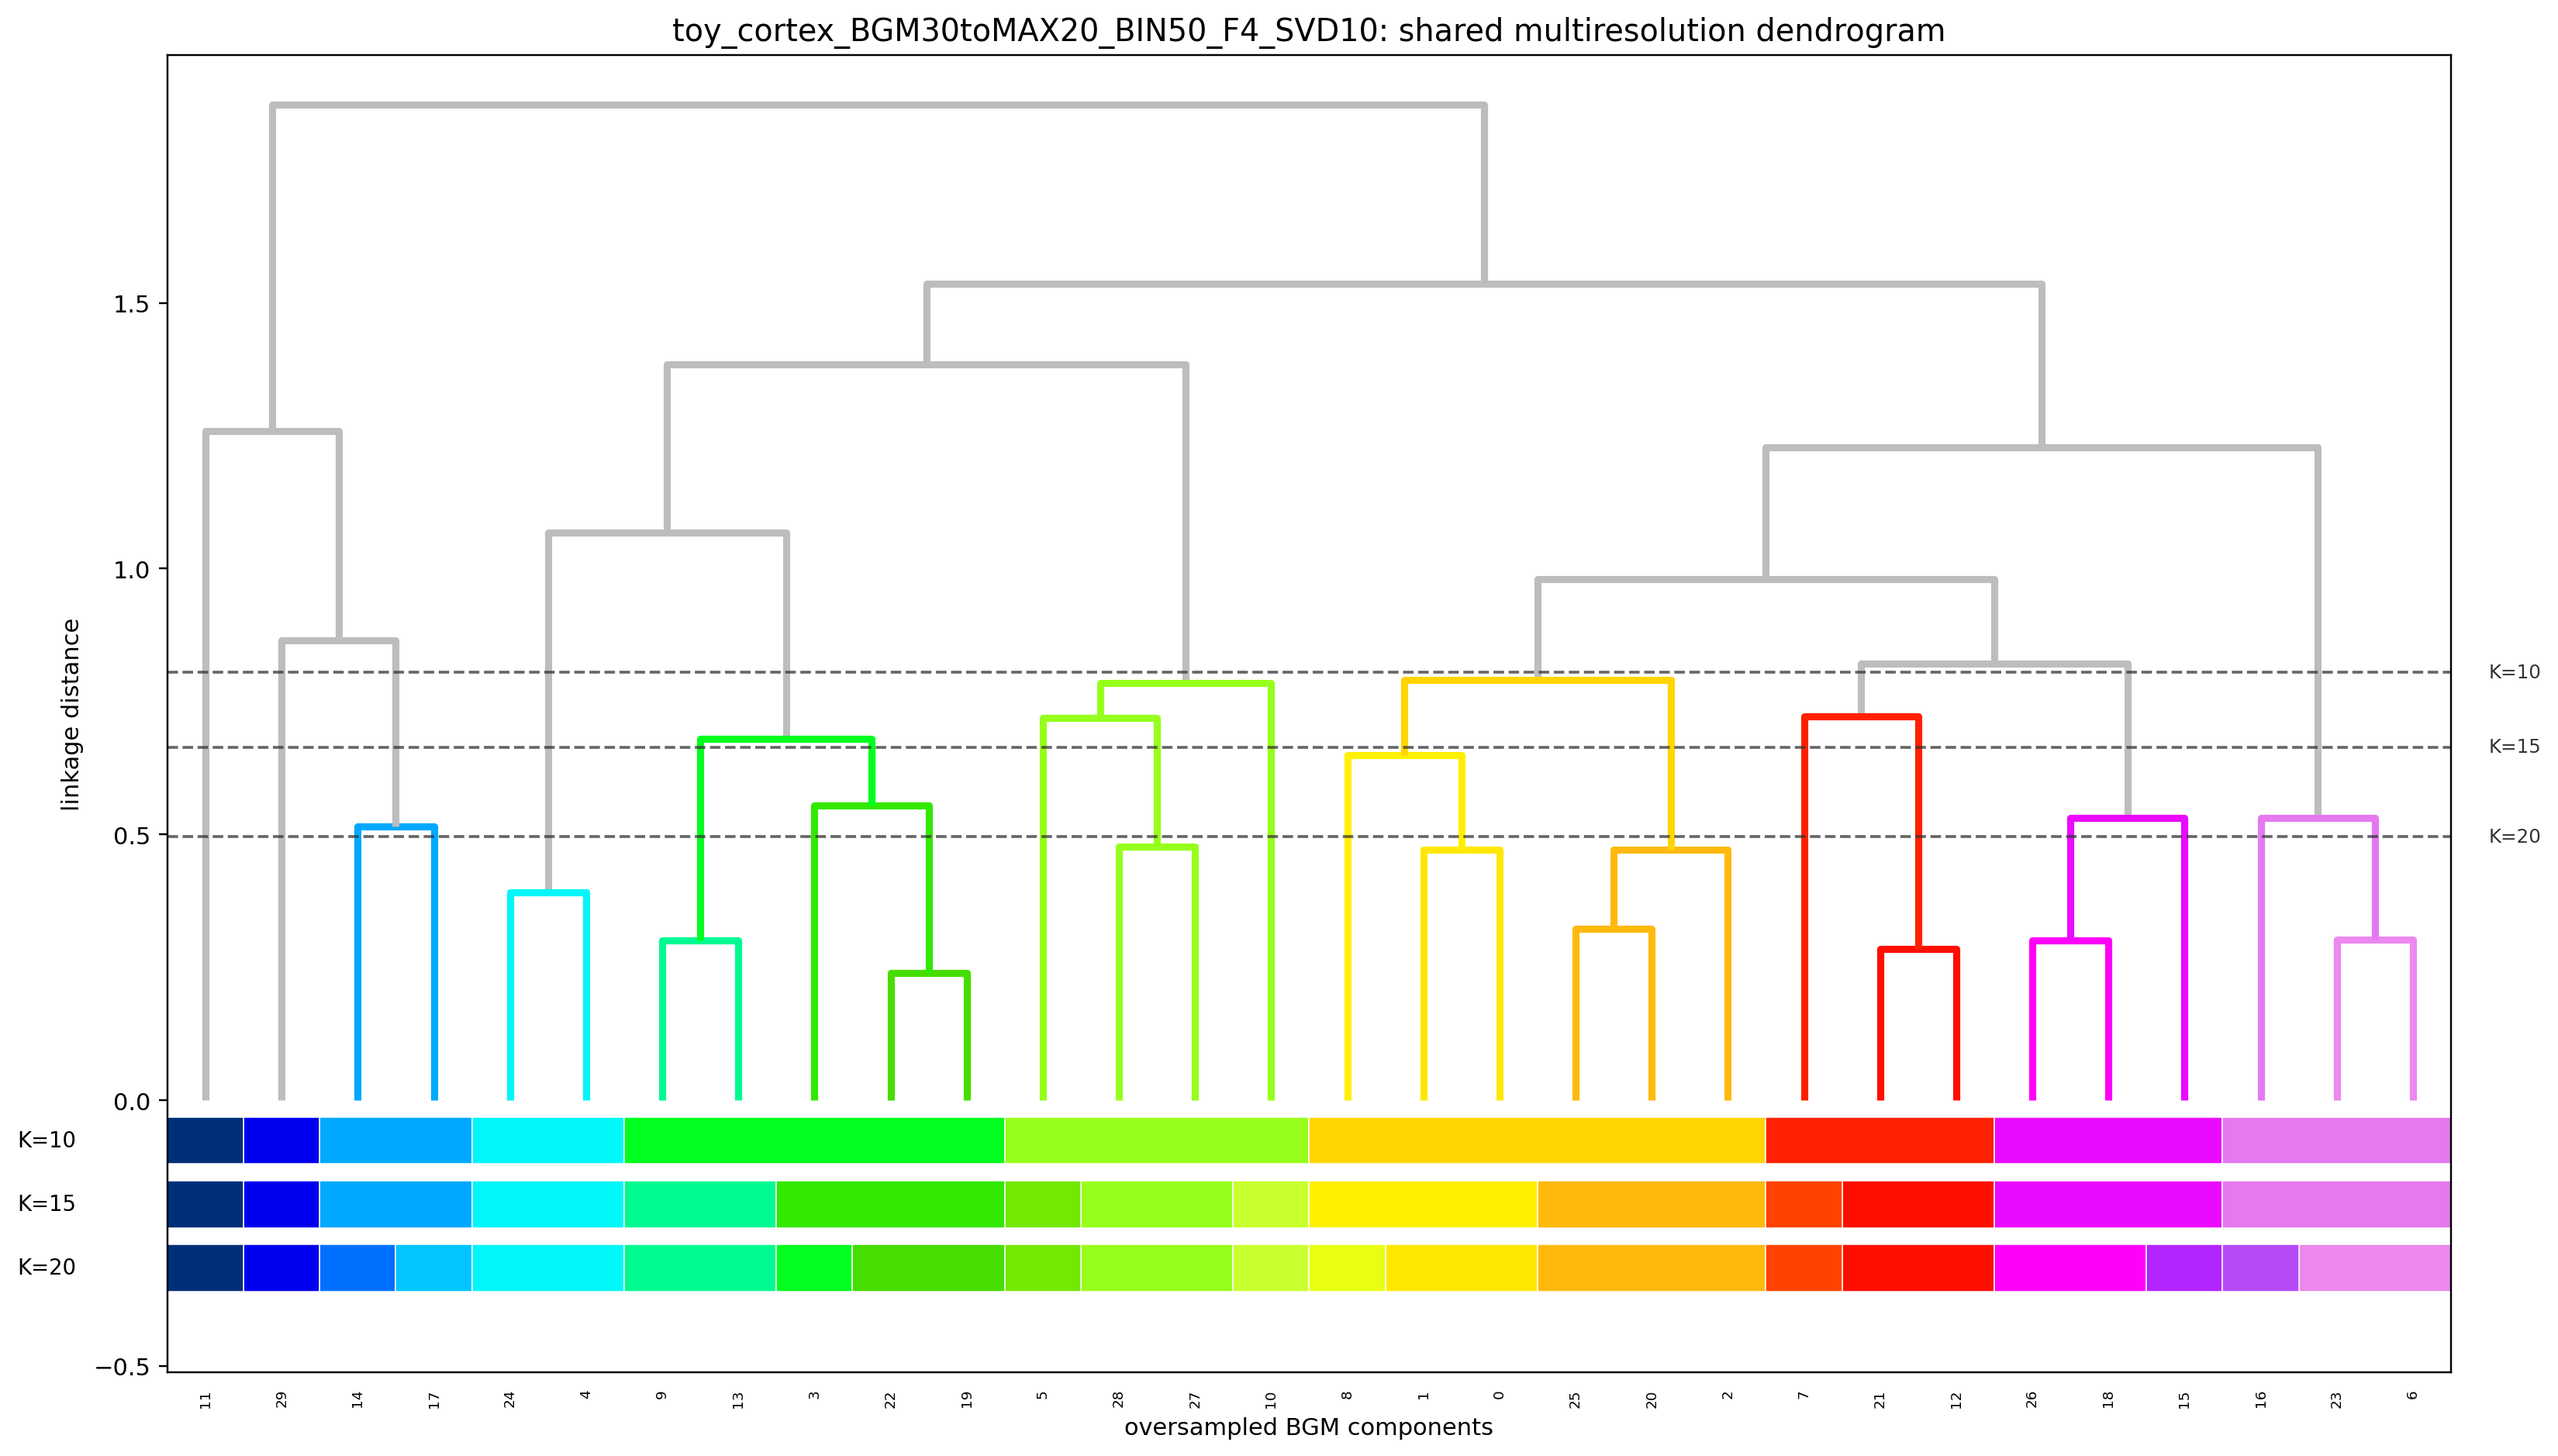

In [16]:
import math
from utils_bgm import shared_bgm_stem_for

cfg     = BGMConfig.from_dict(config)
k_list  = sorted(config["preprocess"]["k_list"])
k_max   = max(k_list)
k_bgm   = math.ceil(config["preprocess"]["bgm_oversample"] * k_max)

shared_stem    = shared_bgm_stem_for(cfg, k_bgm, k_max)
shared_img_dir = shared_image_dir_for(cfg)

dendro_path = shared_img_dir / f"{shared_stem}_multiresolution_dendrogram_allK.png"

from IPython.display import Image, display
display(Image(filename=str(dendro_path), width=900))

### 6.2 Spatial maps — `color_mixed` at each K

`color_mixed` blends the top-2 cluster colours weighted by log-probability,  
giving a smooth visualisation of spatial uncertainty at cluster boundaries.

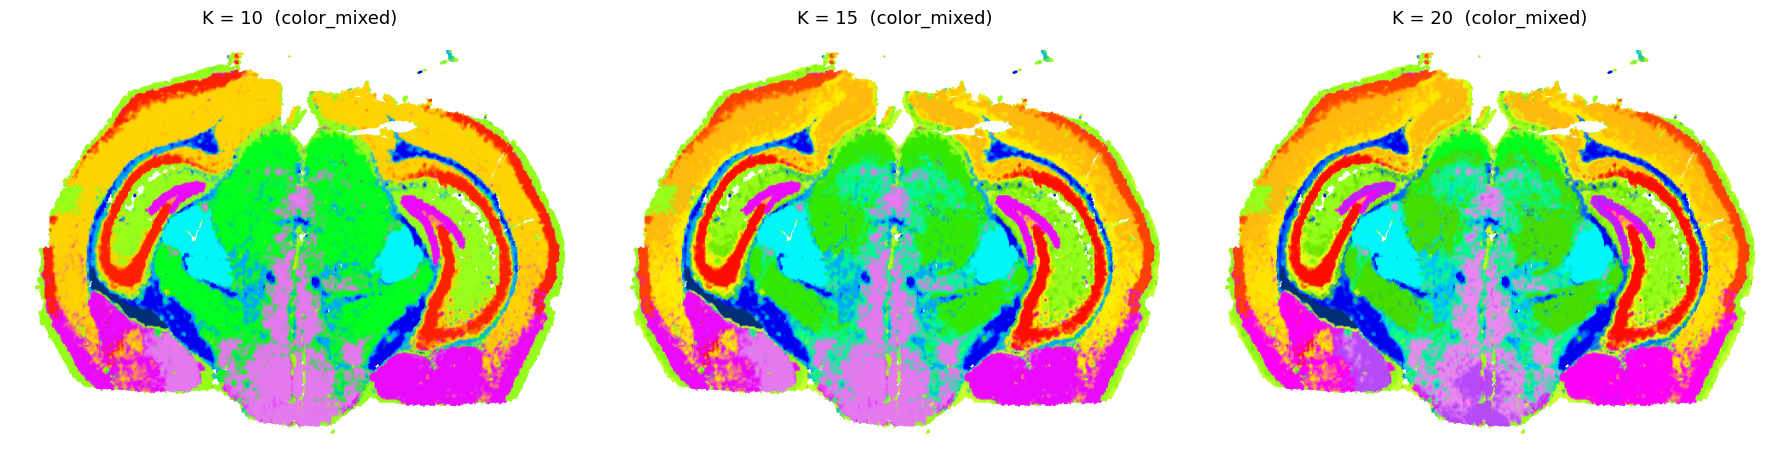

In [ ]:
%matplotlib inline

fig, axes = plt.subplots(1, len(k_list), figsize=(6 * len(k_list), 6))

for ax, k in zip(axes, k_list):
    stem    = bgm_stem_for(cfg, k, k_bgm)
    outdir  = result_dir_for(cfg, k)
    df_bins = pd.read_csv(outdir / f"{stem}_binlevel_FULL.csv")

    ax.scatter(
        df_bins["x"], df_bins["y"],
        c=df_bins["color_mixed"],
        s=3, linewidths=0, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"K = {k}  (color_mixed)", fontsize=13)
    ax.axis("off")

fig.tight_layout()
display(fig)
plt.close()

### 6.3 Hard vs mixed colours — side-by-side (K = 20)

`color_hard` assigns each bin the colour of its single dominant cluster.  
`color_mixed` softens boundaries by blending in the second-best cluster colour.

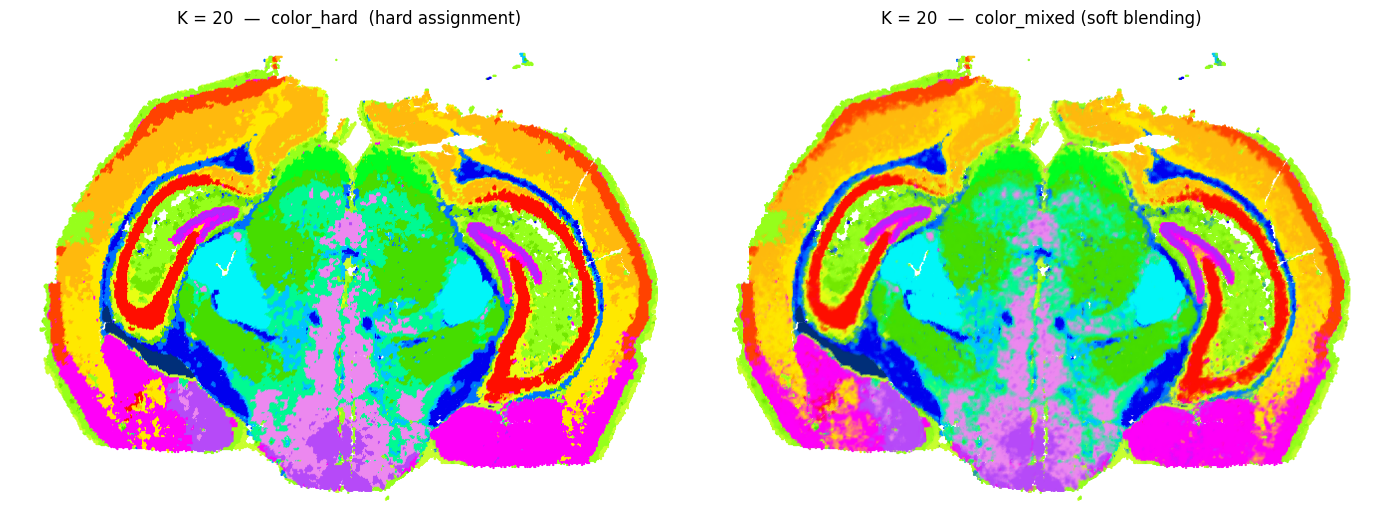

In [ ]:
K_SHOW = 20
stem    = bgm_stem_for(cfg, K_SHOW, k_bgm)
outdir  = result_dir_for(cfg, K_SHOW)
df_bins = pd.read_csv(outdir / f"{stem}_binlevel_FULL.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in [
    (axes[0], "color_hard",  "color_hard  (hard assignment)"),
    (axes[1], "color_mixed", "color_mixed (soft blending)"),
]:
    ax.scatter(
        df_bins["x"], df_bins["y"],
        c=df_bins[col], s=3, linewidths=0, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"K = {K_SHOW}  —  {title}", fontsize=12)
    ax.axis("off")

fig.tight_layout()
plt.show()

### 6.4 Uncertainty map — `compl_p1`

`compl_p1 = 1 − p₁` is the probability mass *not* in the top cluster.  
- **0** → bin is fully assigned to one cluster (certain)  
- **close to 1** → probability is spread across clusters (ambiguous)

High uncertainty typically marks boundary regions or transitional areas.

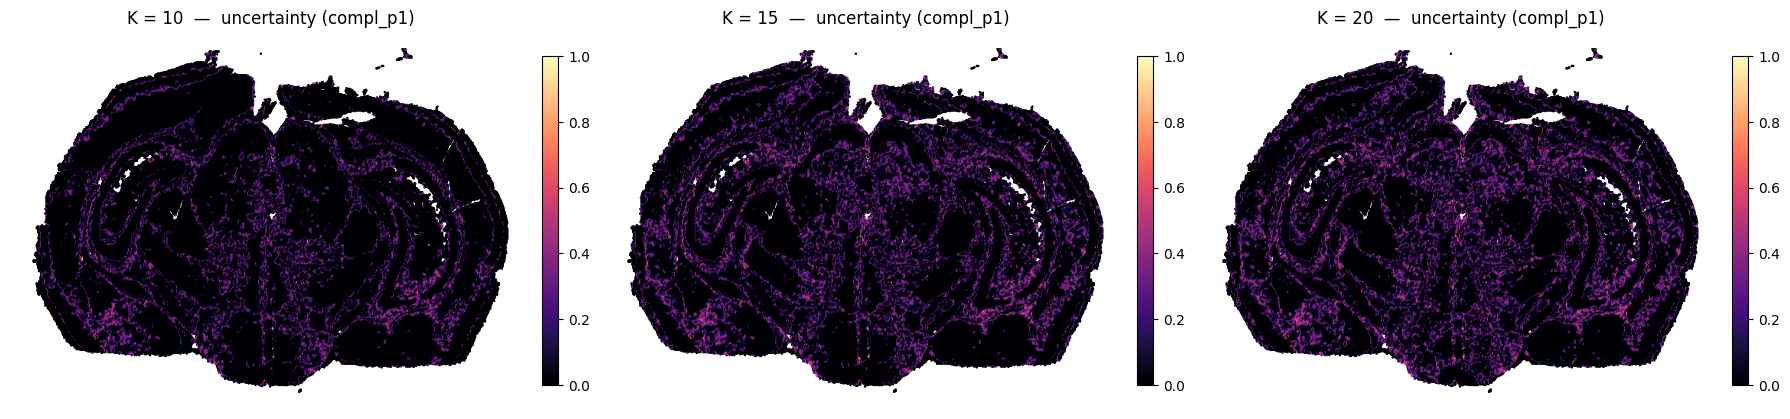

In [19]:
fig, axes = plt.subplots(1, len(k_list), figsize=(6 * len(k_list), 6))

for ax, k in zip(axes, k_list):
    stem    = bgm_stem_for(cfg, k, k_bgm)
    outdir  = result_dir_for(cfg, k)
    df_bins = pd.read_csv(outdir / f"{stem}_binlevel_FULL.csv")

    sc = ax.scatter(
        df_bins["x"], df_bins["y"],
        c=df_bins["compl_p1"],
        cmap="magma", vmin=0, vmax=1,
        s=3, linewidths=0, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"K = {k}  —  uncertainty (compl_p1)", fontsize=12)
    ax.axis("off")
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)

fig.tight_layout()
plt.show()

### 6.5 Cluster posteriors (K = 20)

Each bin carries a soft probability vector over all K clusters.  
Below we plot the posterior for a few selected clusters — these are spatial probability maps,
not hard assignments.

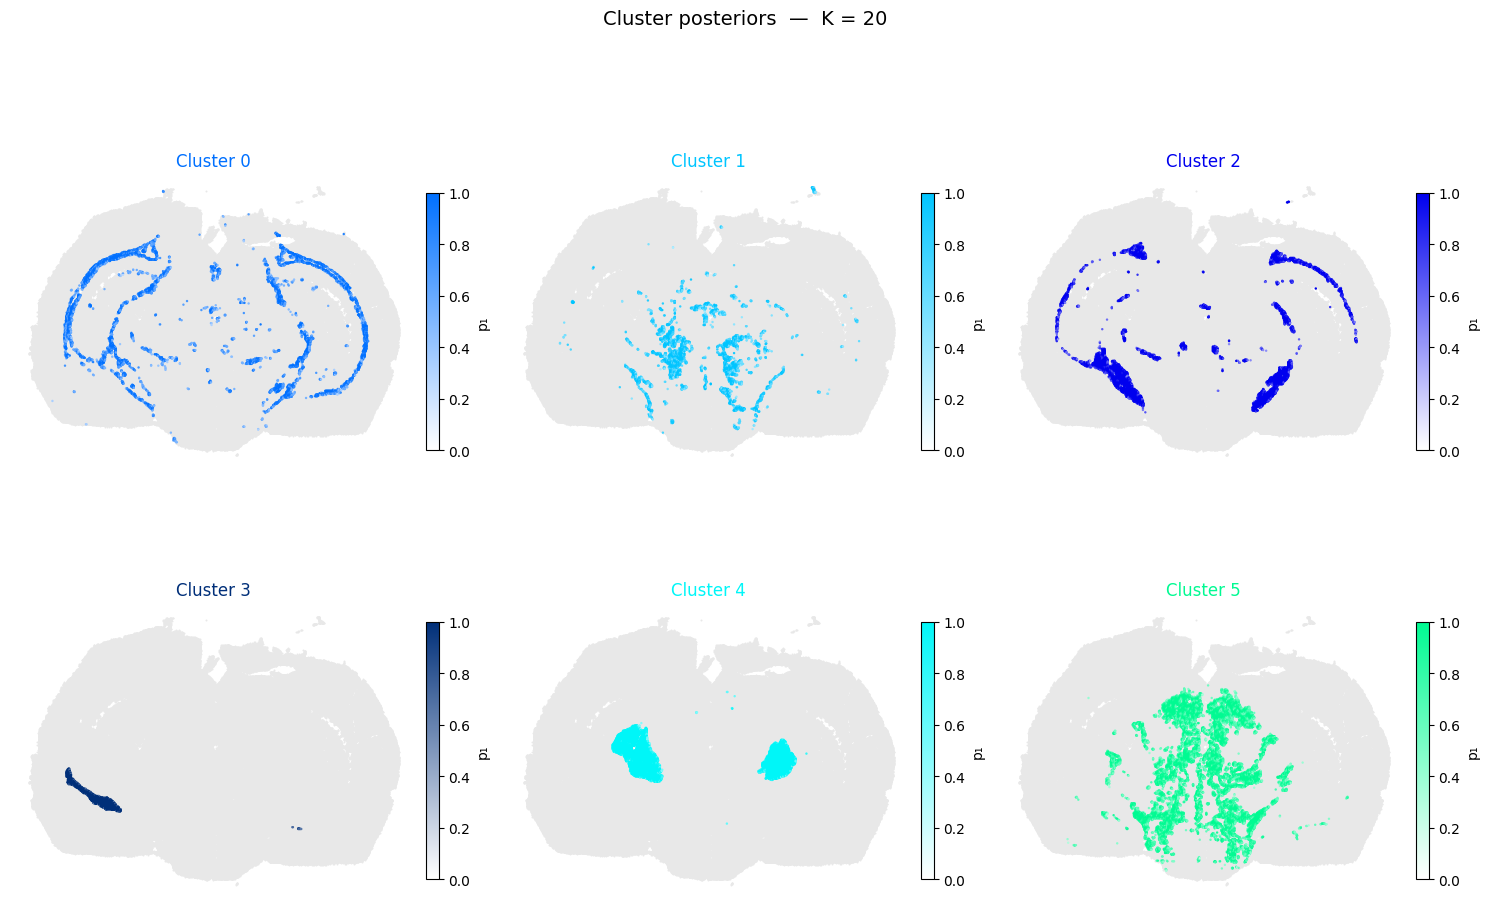

In [20]:
K_SHOW         = 20
CLUSTERS_SHOW  = [0, 1, 2, 3, 4, 5]   # edit to pick different clusters

stem    = bgm_stem_for(cfg, K_SHOW, k_bgm)
outdir  = result_dir_for(cfg, K_SHOW)
df_bins = pd.read_csv(outdir / f"{stem}_binlevel_FULL.csv")

# p1 is the top-cluster probability; to get per-cluster posteriors we need
# to enable save_transcript_proba=True or reconstruct from p1/p2.
# Here we use p1 masked by cluster assignment as an approximation:
# bins assigned to cluster C show their top-cluster probability p1.

n_cols  = 3
n_rows  = int(np.ceil(len(CLUSTERS_SHOW) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

# Load the colour table to get each cluster's canonical colour
from utils_bgm import shared_bgm_stem_for
shared_outdir = shared_result_dir_for(cfg)
shared_stem   = shared_bgm_stem_for(cfg, k_bgm, k_max)
df_colors = pd.read_csv(outdir / f"colors_{stem}.csv")

for ax, c in zip(axes, CLUSTERS_SHOW):
    mask     = df_bins["cluster"] == c
    df_c     = df_bins[mask]
    hex_col  = df_colors.loc[df_colors["cluster"] == c, "color_hex"].values[0]
    cmap     = mcolors.LinearSegmentedColormap.from_list(
        f"c{c}", ["#ffffff", hex_col]
    )

    # background: all bins in grey
    ax.scatter(
        df_bins["x"], df_bins["y"],
        c="#e8e8e8", s=2, linewidths=0, rasterized=True,
    )
    # foreground: bins assigned to this cluster, coloured by p1
    sc = ax.scatter(
        df_c["x"], df_c["y"],
        c=df_c["p1"],
        cmap=cmap, vmin=0, vmax=1,
        s=3, linewidths=0, rasterized=True,
    )
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"Cluster {c}", fontsize=12, color=hex_col)
    ax.axis("off")
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, label="p₁")

# hide unused axes
for ax in axes[len(CLUSTERS_SHOW):]:
    ax.set_visible(False)

fig.suptitle(f"Cluster posteriors  —  K = {K_SHOW}", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

---
## 7. Output files

After running this notebook you will find:

```
preprocess_cache_toy_cortex/
  toy_cortex_BIN200_F3_SVD10.npz
  toy_cortex_BIN200_F3_SVD10_preprocess_config.json

results_toy_cortex/
  shared_BGM/SVD10/
    *_cluster_color_table_allK.csv
    *_multiresolution_dendrogram_allK.png
    *_shared_bgm_config.json
  K10/SVD10/
    *_FULL.h5ad             ← AnnData (transcript-level)
    *_binlevel_FULL.csv     ← bin-level table (see column legend below)
    colors_*.csv            ← cluster colour table
    images/
      *_cut_dendrogram.png
  K15/SVD10/  ...
  K20/SVD10/  ...
```

### Column legend — `_binlevel_FULL.csv`

| Column | Description |
|--------|-------------|
| `x`, `y` | Bin spatial coordinates |
| `bin_id` | Global bin index |
| `cluster` | Index of the dominant cluster (0-based) |
| `second_cluster` | Index of the second-best cluster |
| `p1` | Probability of the dominant cluster |
| `p2` | Probability of the second-best cluster |
| `compl_p1` | `1 − p1` — uncertainty (0 = certain, ~1 = ambiguous) |
| `mix_t` | Blend weight toward second cluster: `log1p(α·p2) / (log1p(α·p1) + log1p(α·p2))` |
| `cmap_pos` | Cluster position along the dendrogram colour axis [0, 1] |
| `color_hard` | Hex colour of the dominant cluster |
| `color_mixed` | Hex colour blending top-2 clusters by log-probability — **recommended for visualisation** |